# Homework 01: Binary Classification with Neural Networks

## Due: Sunday Sept 6th @ 11:59 (with 2-hour + 1-minute grace period) and worth 85 points

## Note: For this first assignment, there will be no late points if received by Sept 11th @ 11:59 pm

In this assignment, you'll build your first deep learning models using **Keras**, a high-level deep learning framework built on TensorFlow.

We’ll solve a binary classification task, using the Wisconsin Breast Cancer dataset. 

You’ll start by training a simple baseline model, and then explore a series of alternate network designs.  For each model, you’ll:

- Track training loss and accuracy over epochs
- Report final test set performance (loss and accuracy)

The goal is to begin developing an intuition for how network design choices influence performance—and to get comfortable with the end-to-end modeling workflow in Keras.


There are 12 graded problems, each worth 7 points, and you get 1 point free. 


In [1]:
# Useful Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

random_seed = 42

In [2]:
# Utility function: Plotting Training Loss (x-entropy) and Accuracy
# We'll replace this with a different function train_and_test when we develop more
# training techniques.

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')


## Prelude: Load and Explore the Wisconsin Breast Cancer Dataset

You should **always** perform EDA when working with a new dataset. We've seen this one before, but its always worth becoming familiar with the data before building a model!

In [3]:
# Load dataset with as DataFrame for EDA
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)

df = data.frame  # Convenient alias for combined data+target

In [4]:
# Uncomment and look at this

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

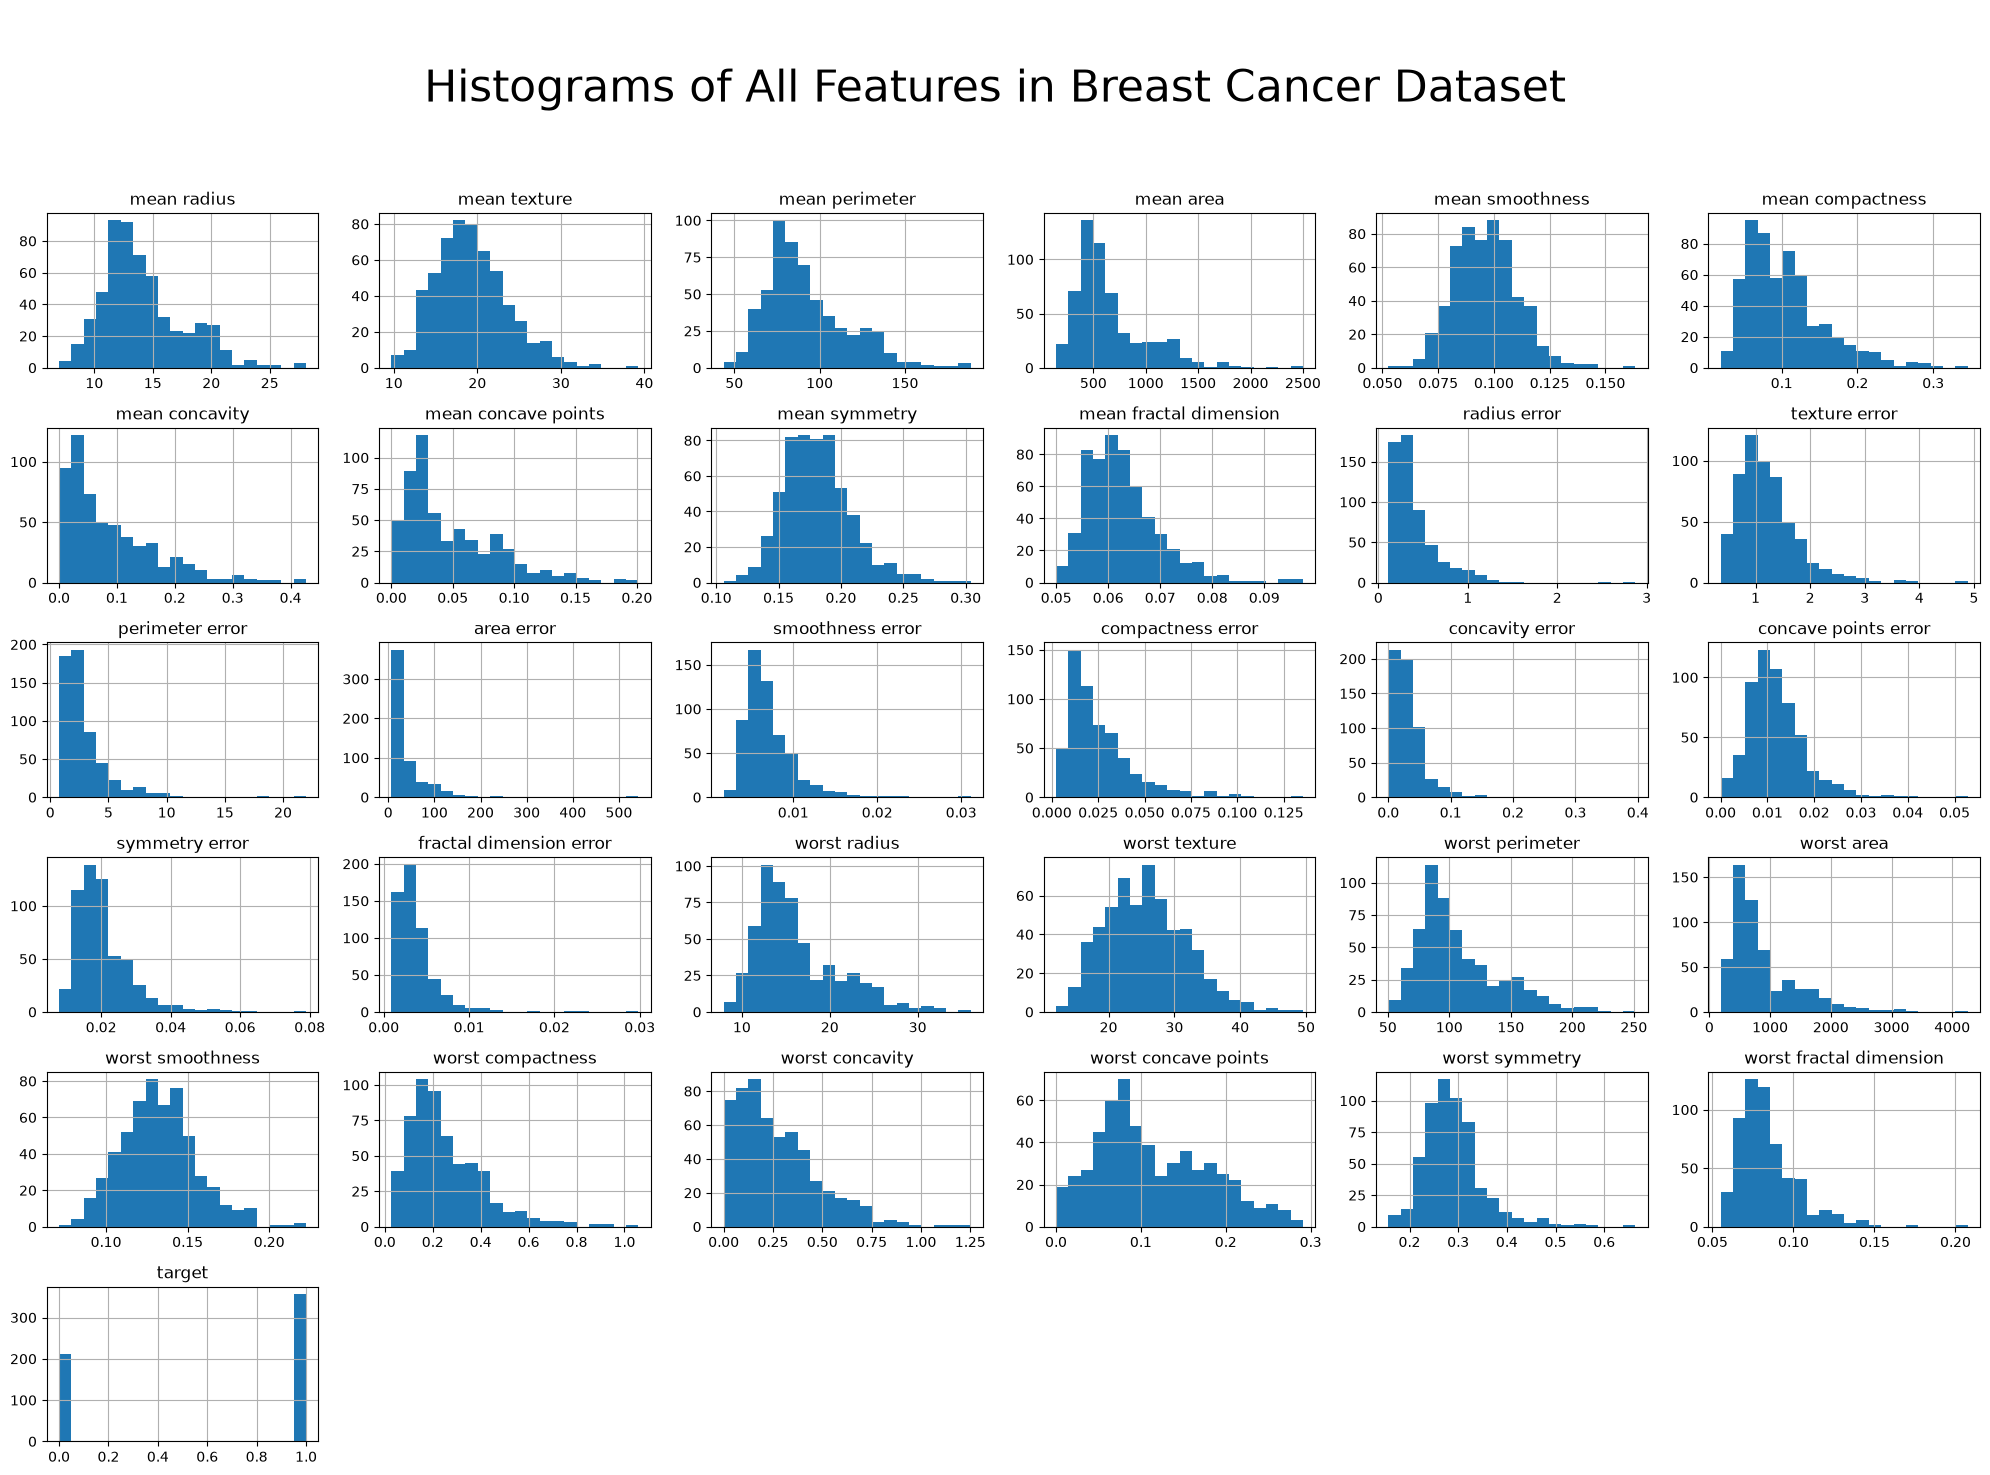

In [5]:
# Uncomment and look at this

fig = df.hist(bins=20, figsize=(20, 15), layout=(6, 6))
plt.suptitle("\nHistograms of All Features in Breast Cancer Dataset", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the title
plt.show()

## Problem One: Dealing with unbalanced target variables and establishing a baseline model

### Part A: Compute the imbalance of the target

Neural networks work best with standardized datasets; for classification tasks, it is also important
to account for an unbalanced target. Let's create our `X,y` data structure and look at the target more closely. 

1. **Convert the data to NumPy arrays:** Extract the feature matrix `X` and the target vector `y` from the DataFrame, and
convert them to NumPy arrays. Print the shapes of `X` and `y` to confirm the conversion was successful.  

2. **Check for class imbalance:**
   Use `Counter` (or another appropriate method) to print the frequency of each class label in the target array `y`. This will help you understand how balanced (or imbalanced) the classes are.

3. **Compute the proportion of class 1:**
   Calculate what percentage of the samples belong to class label `1` and provide your answer in the graded question. 



In [6]:
# A.1

# Extract the feature matrix X and the target vector y from the DataFrame as NumPy arrays
X = df.drop(columns=['target']).to_numpy()
y = df['target'].to_numpy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (569, 30)
y shape: (569,)


In [7]:
# A.2

# Frequency of each class label in the target
class_counts = Counter(y.tolist())        # .tolist() gives plain Python ints as keys
print(f'Class counts: {dict(class_counts)}')

for label, count in sorted(class_counts.items()):
    print(f'  class {label} ({data.target_names[label]}): {count} samples  ({count / len(y):.2%})')

Class counts: {0: 212, 1: 357}
  class 0 (malignant): 212 samples  (37.26%)
  class 1 (benign): 357 samples  (62.74%)


In [8]:
# A.3

# Set a1a to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1a = np.mean(y == 1)             # fraction of samples whose label is 1

In [9]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')                     

a1a = 0.6274


### Part B: Perform a stratified test/train split

In classification problems with imbalanced datasets, it's important to address the class imbalance so that the model doesn't become biased toward the majority class. There are two common strategies:

* **Resampling** the dataset to balance the classes (by oversampling the minority class or undersampling the majority class).
* **Adjusting the loss function** so that errors on minority classes have more influence during training.

In this problem, you'll explore the second approach—using class weights to influence how the model learns.

This strategy involves two key steps:

1. **Preserve class proportions in the train/test split**
   Use the  parameter `stratify=y`in `train_test_split` to ensure that both the training and testing sets maintain the same class distribution as in the original target.

2. **Apply class weighting during training**
   Use the `class_weight` parameter in the `fit` function to assign different weights to each class when computing the loss. This helps ensure that the model pays appropriate attention to both common and rare classes.


**We'll do the first step now, perform standardization, and then do the second step in Part C.** 

In [10]:
# Perform train-test split, keeping both stratified, use random_state = random_seed and test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y,
)

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (455, 30)   y_train: (455,)
X_test:  (114, 30)   y_test:  (114,)


**(Digression:** We must perform standardization **after** the test/train split, or else we're letting
information about the mean and standard deviation of the test set influence training--a classic case of *data leakage*.
**)**

In [11]:
# As usual, standardize the features

# Fit the scaler on the training data only, then apply the *same* transformation
# to the test data -- this avoids the data leakage described above.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'X_train mean: {X_train.mean():.4f}   std: {X_train.std():.4f}')
print(f'X_test  mean: {X_test.mean():.4f}   std: {X_test.std():.4f}')

X_train mean: -0.0000   std: 1.0000
X_test  mean: 0.0296   std: 0.9626


Let's see if the stratification worked! Assign `a1b` to the percentage of 1's in `y_train` (and convince yourself that if it is approximately correct, then so must be `y_test`). 

In [12]:
# Set a1b to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1b = np.mean(y_train == 1)             # fraction of training samples whose label is 1

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}')  

a1b = 0.6264


## Part C: Train a baseline model with class weighting

Now we'll build a baseline model with class weighting during training. 

To compute the weight for class $i$, use the following formula:

$$
\text{weight}_i = \frac{n}{k \cdot n_i},
$$

where:

* $n$ is the total number of samples,
* $n_i$ is the number of samples in class $i$,
* $k$ is the total number of classes.

This formula scales the loss so that each class contributes approximately equally during training—without changing the number of training samples.

To apply class weighting during training, we use the parameter `class_weight=weights` in the `fit` function, where `weights` is a dictionary 

    { 0 : weight_0, 1 : weight_1 }

as specified in the formula above. 

**Note**: As an alternative, you can also use `sklearn.utils.class_weight` to do the calculation. 

**TODO: Complete the template to**

-  Build a network consisting of a single logistic regression classifier (done for you!)
-  Compile it using the same parameters as shown in the coding video, except we will use the `Adam` optimizer:
>          optimizer='adam'
-  Train it for **100** epochs, calculating the class weights explicitly as shown or using `sklearn.utils.class_weight` (look up the docs!)
-  Display the training loss and accuracy curves using `plot_history`
-  Complete the graded question 

Training samples per class: {0: 170, 1: 285}
Class weights (explicit formula): {0: 1.338235294117647, 1: 0.7982456140350878}
Class weights (sklearn balanced): {0: 1.338235294117647, 1: 0.7982456140350878}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

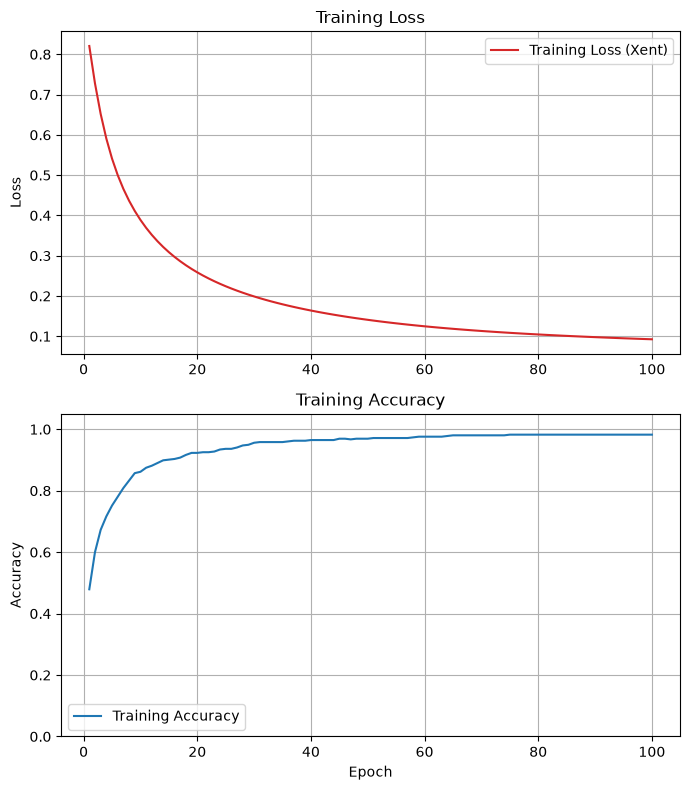

Final Training Loss:     0.0925
Final Training Accuracy: 0.9824


In [14]:
# Try a baseline model consisting of a single logistic regression classifier.
# This is very similar to sklearn's LogisticRegression model.

n_epochs = 100

# Class weights, computed on the training set:  weight_i = n / (k * n_i)
n = len(y_train)                          # total number of training samples
k = len(np.unique(y_train))               # number of classes
train_counts = Counter(y_train.tolist())  # n_i for each class i
weights = {label: n / (k * count) for label, count in sorted(train_counts.items())}
print(f'Training samples per class: {dict(sorted(train_counts.items()))}')
print(f'Class weights (explicit formula): {weights}')

# Sanity check: sklearn's "balanced" mode uses exactly the same formula
sk_weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
print(f'Class weights (sklearn balanced): {dict(zip(np.unique(y_train).tolist(), sk_weights.tolist()))}')

# We use Sequential to build a simple classification network from
# a list of layers, and print the summary

keras.utils.set_random_seed(random_seed)   # reproducible weight initialization

model_baseline = keras.Sequential(
    [
       keras.layers.Input(shape=(X_train.shape[1],)),     # Explicit input layer
       keras.layers.Dense(1, activation="sigmoid")
    ]
)
model_baseline.summary()

# Compile with binary cross-entropy loss and accuracy metric, using the Adam optimizer
model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

# Train for 100 epochs with class weighting
history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=n_epochs,
    class_weight=weights,
    verbose=0,
)

plot_history(history_baseline)

In [15]:
# Set a1c to the final training accuracy (at epoch 100)
# You MUST use an expression here, not a constant from inspecting the results

a1c = history_baseline.history['accuracy'][-1]

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1c = {a1c:.4f}')  

a1c = 0.9824


### Part D: Testing

- Calculate the testing loss and accuracy and answer the graded question.
- Print out both with appropriate labels
- Answer the graded question

In [17]:
# Your code here

# Evaluate the trained baseline model on the held-out test set
test_loss_baseline, test_acc_baseline = model_baseline.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss:     {test_loss_baseline:.4f}')
print(f'Test Accuracy: {test_acc_baseline:.4f}')

Test Loss:     0.1289
Test Accuracy: 0.9561


In [18]:
# Set a1d to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a1d = test_acc_baseline

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1d = {a1d:.4f}') 

a1d = 0.9561


## Problem Two: Explore alternate network designs

For the remaining problems, you will experiment with several different network designs.

For Problem Two, redo the work you did in Parts C and D of Problem One, but with a network with a single hidden layer of 16 neurons, using the sigmoid activation function, which
will have the following summary chart (the layer name may be different than shown here):

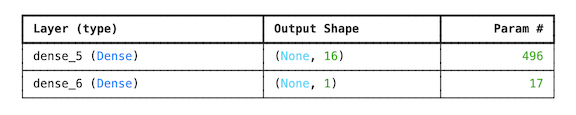


Then answer the graded questions.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Hidden layer of 16: training ---


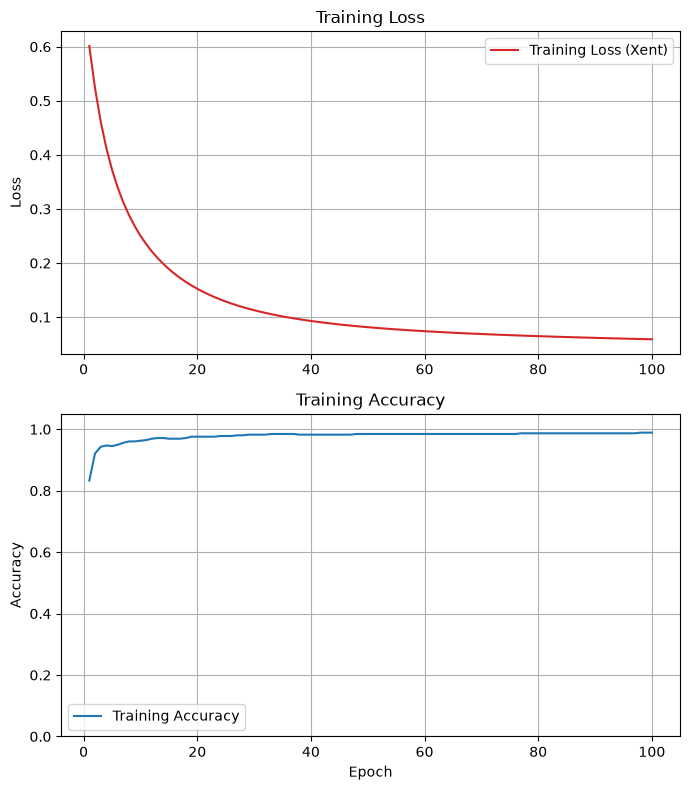

Final Training Loss:     0.0591
Final Training Accuracy: 0.9890



--- Hidden layer of 16: testing ---
Test Loss:     0.1051
Test Accuracy: 0.9474


In [20]:
# Your code here, add additional cells if you wish

# Problems Two through Five repeat Parts C and D with different architectures,
# so the shared steps (summary, compile, train with class weights, plot, test)
# are wrapped in a helper.  Each problem still defines its own network explicitly.

def fit_and_evaluate(model, name):
    """Compile and train `model` with class weighting, plot the training
    curves, then evaluate on the test set.
    Returns (history, test_loss, test_accuracy)."""
    model.summary()

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=n_epochs, class_weight=weights, verbose=0)

    print(f'\n--- {name}: training ---')
    plot_history(history)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\n--- {name}: testing ---')
    print(f'Test Loss:     {test_loss:.4f}')
    print(f'Test Accuracy: {test_acc:.4f}')

    return history, test_loss, test_acc


# Problem Two: one hidden layer of 16 sigmoid neurons
keras.utils.set_random_seed(random_seed)

model_16 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(16, activation='sigmoid'),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)

history_16, test_loss_16, test_acc_16 = fit_and_evaluate(model_16, 'Hidden layer of 16')

In [21]:
# Set a2a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a2a = history_16.history['accuracy'][-1]

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.9890


In [23]:
# Set a2b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a2b = test_acc_16

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.9474


## Problem Three: Explore alternate network designs


For Problem Three, redo the work you did in Parts C and D of Problem One, but with a network with a  hidden layer of 64 neurons, 
using the sigmoid activation function, which
will have the following summary chart:

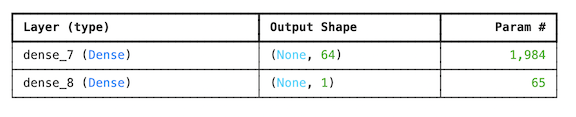


Then answer the graded questions.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Hidden layer of 64: training ---


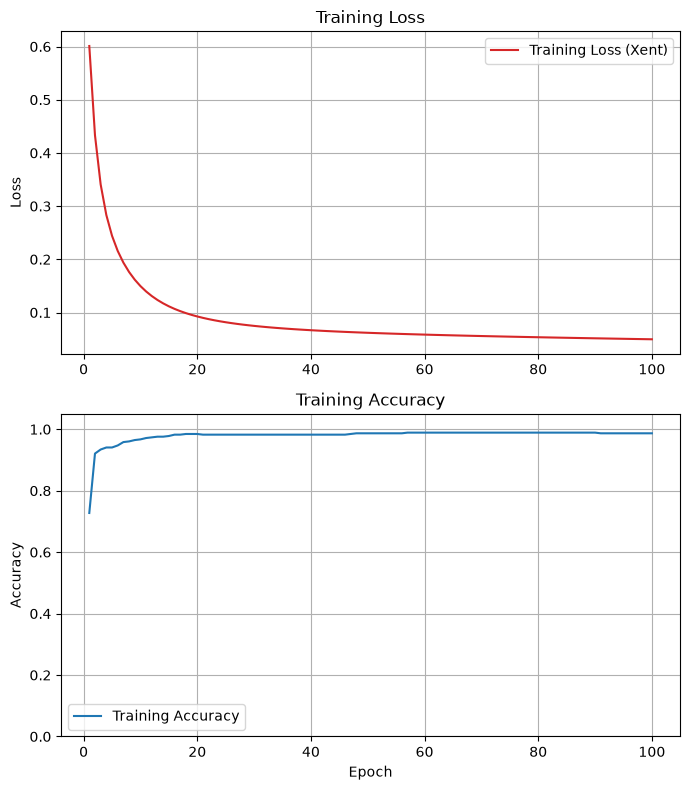

Final Training Loss:     0.0497
Final Training Accuracy: 0.9868



--- Hidden layer of 64: testing ---
Test Loss:     0.0922
Test Accuracy: 0.9474


In [25]:
# Your code here, add additional cells if you wish

# Problem Three: one hidden layer of 64 sigmoid neurons
keras.utils.set_random_seed(random_seed)

model_64 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(64, activation='sigmoid'),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)

history_64, test_loss_64, test_acc_64 = fit_and_evaluate(model_64, 'Hidden layer of 64')

In [26]:
# Set a3a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a3a = history_64.history['accuracy'][-1]

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.9868


In [28]:
# Set a3b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a3b = test_acc_64

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.9474


## Problem Four: Explore alternate network designs


For Problem Four, redo the work you did in Parts C and D of Problem One, but with a network with  a hidden layer of 256 neurons, using the sigmoid activation function, which
will have the following summary chart:

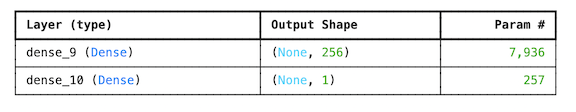


Then answer the graded questions.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,193 (32.00 KB)

 Trainable params: 8,193 (32.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Hidden layer of 256: training ---


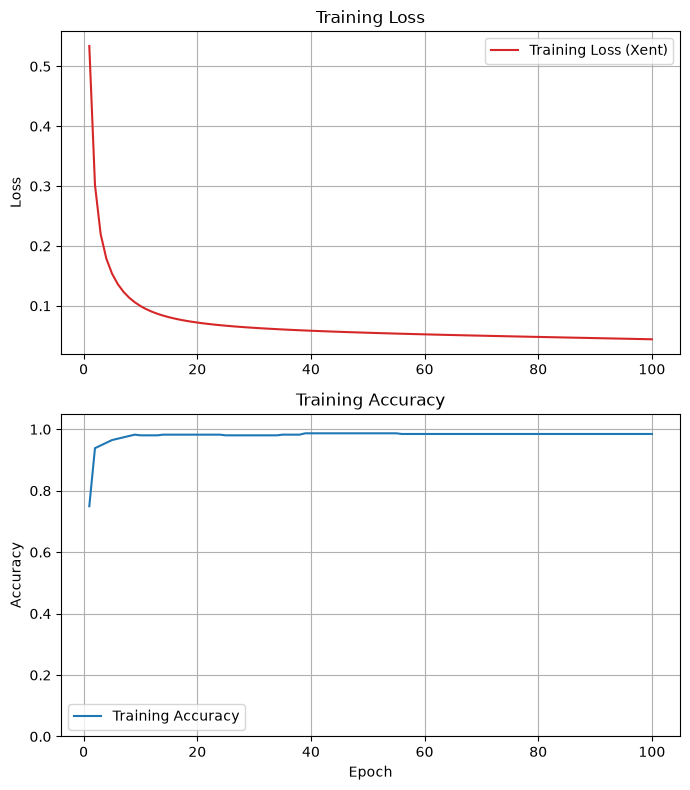

Final Training Loss:     0.0441
Final Training Accuracy: 0.9846



--- Hidden layer of 256: testing ---
Test Loss:     0.0855
Test Accuracy: 0.9474


In [30]:
# Your code here, add additional cells if you wish

# Problem Four: one hidden layer of 256 sigmoid neurons
keras.utils.set_random_seed(random_seed)

model_256 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(256, activation='sigmoid'),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)

history_256, test_loss_256, test_acc_256 = fit_and_evaluate(model_256, 'Hidden layer of 256')

In [31]:
# Set a4a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a4a = history_256.history['accuracy'][-1]

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.9846


In [33]:
# Set a4b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a4b = test_acc_256

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.9474


## Problem Five: Explore alternate network designs


For Problem Five, redo the work you did in Parts C and D of Problem One, but with a network with two hidden layers of 64  and 32 neurons, using the sigmoid activation function for all layers, which
will have the following summary chart:

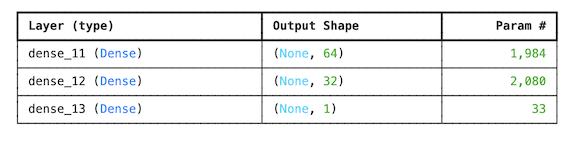

Then answer the graded questions.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Hidden layers of 64 and 32: training ---


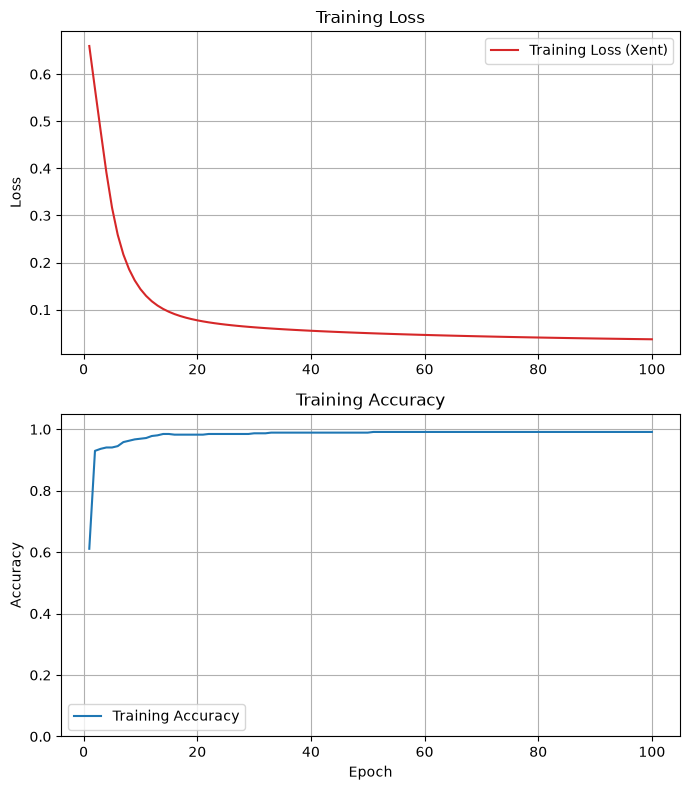

Final Training Loss:     0.0372
Final Training Accuracy: 0.9912

--- Hidden layers of 64 and 32: testing ---
Test Loss:     0.1258
Test Accuracy: 0.9474


In [35]:
# Your code here, add additional cells if you wish

# Problem Five: two hidden layers of 64 and 32 sigmoid neurons
keras.utils.set_random_seed(random_seed)

model_64_32 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(64, activation='sigmoid'),
        keras.layers.Dense(32, activation='sigmoid'),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)

history_64_32, test_loss_64_32, test_acc_64_32 = fit_and_evaluate(model_64_32, 'Hidden layers of 64 and 32')

In [36]:
# Set a5a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a5a = history_64_32.history['accuracy'][-1]

In [37]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.9912


In [38]:
# Set a5b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a5b = test_acc_64_32

In [39]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.9474


## Reflection Questions:

You won't be graded on these, and you don't need to write anything, but here are some things to think about after completing the experiments. 

1. After the baseline, we tried wider and wider models, and then a deeper model. Which idea worked better in terms of training accuracy (at least for this data split)? What model would you try next to test this hypothesis?

2. What effect did these experiments have on the testing accuracy?  Can you suggest an explanation for this? Rather than me giving you ideas, have a conversation with `ChatGPT` in which you describe your experiments, and the dataset, and explore with it why the testing results turned out this way.

3. What do you think would happen if you tried running the same experiments with a different random seed (and hence a different split in a fairly small dataset)?  

### Reflection notes

These aren't graded, but I wanted to write down what I saw while it's fresh.

| Model | Params | Train acc | Train loss | Test acc | Test loss |
|---|---|---|---|---|---|
| Logistic regression baseline | 31 | 0.9824 | 0.0925 | 0.9561 | 0.1289 |
| 1 hidden layer, 16 | 513 | 0.9890 | 0.0591 | 0.9474 | 0.1051 |
| 1 hidden layer, 64 | 2,049 | 0.9868 | 0.0497 | 0.9474 | 0.0922 |
| 1 hidden layer, 256 | 8,193 | 0.9846 | 0.0441 | 0.9474 | 0.0855 |
| 2 hidden layers, 64 and 32 | 4,097 | 0.9912 | 0.0372 | 0.9474 | 0.1258 |

On the first question, wider or deeper: going wider did almost nothing. Training accuracy went 0.9890, then 0.9868, then 0.9846 as the hidden layer grew from 16 to 64 to 256 neurons. It slipped a little, even though the loss kept dropping the whole time. The two-layer 64/32 network won on both counts, with the best training accuracy at 0.9912 and the lowest loss at 0.0372, and it did that with half the parameters of the 256 model. So on this split, depth beat width. To check that properly I'd try three hidden layers with a similar parameter count, something like 64/32/16. I'd also give the wide models more than 100 epochs, because their loss curves hadn't flattened out yet and it's a bit unfair to judge them mid-descent.

The test results are the part that surprised me. Every model with a hidden layer got the exact same test accuracy, 0.9474, which is 108 out of 114. Plain logistic regression got 109. The biggest network I built lost to the baseline by a single sample.

My best guess at why: once the features are standardized, this dataset is nearly linearly separable, so a single sigmoid unit already gets most of what there is to get. The extra capacity goes into memorizing quirks of the 455 training rows, which is why training accuracy climbs and test accuracy doesn't. Mild overfitting, basically. The other thing is that 114 test samples is tiny. One sample is almost a full percentage point, so I don't think any of these gaps mean much.

Test loss is more interesting than test accuracy here. It kept falling as the models got wider (0.129, 0.105, 0.092, 0.086), so the wide models are more confident on the test set even though they aren't getting more answers right. The deep model's test loss went back up to 0.126, which looks like the start of overconfidence. Before I'd believe any ranking of these five models I'd want a validation split, or better, cross-validation.
